In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data_science_job.csv")

In [12]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
18280,13941,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7.0,500-999,Pvt Ltd,200.0,0.0
9418,15126,city_67,0.855,Male,No relevent experience,no_enrollment,NaN,NaN,0.0,NaN,NaN,62.0,0.0
17656,30553,city_103,0.920,Male,No relevent experience,no_enrollment,NaN,NaN,4.0,NaN,Pvt Ltd,34.0,0.0
10577,29380,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,5000-9999,Pvt Ltd,7.0,0.0
2051,7406,city_67,0.855,Male,Has relevent experience,no_enrollment,Masters,STEM,11.0,50-99,Pvt Ltd,8.0,0.0


In [4]:
df.shape

(19158, 13)

In [13]:
df.isnull().mean()

enrollee_id               0.000000
city                      0.000000
city_development_index    0.025003
gender                    0.235306
relevent_experience       0.000000
enrolled_university       0.020148
education_level           0.024011
major_discipline          0.146832
experience                0.003393
company_size              0.309949
company_type              0.320493
training_hours            0.039983
target                    0.000000
dtype: float64

In [21]:
cols=[]
for var in df.columns:
    if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0:
         cols.append(var)

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [26]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [27]:
new_df = df[cols].dropna()

In [29]:
new_df.shape, df.shape

((17182, 5), (19158, 13))

(array([8.00907579e-03, 1.32123691e-02, 1.30125765e-02, 1.07714251e-02,
        1.18138211e-02, 9.14702474e-03, 9.31207077e-03, 9.72902916e-03,
        7.46181790e-03, 4.71684182e-03, 5.28147298e-03, 5.14248684e-03,
        4.54310915e-03, 3.70050574e-03, 3.75262553e-03, 4.35200322e-03,
        3.16193448e-03, 1.31168161e-03, 1.78075980e-03, 1.58096724e-03,
        1.60702714e-03, 1.65914694e-03, 1.68520684e-03, 1.57228061e-03,
        1.77207317e-03, 5.21197991e-04, 5.64631157e-04, 7.38363821e-04,
        5.82004423e-04, 5.99377690e-04, 6.34124222e-04, 5.90691056e-04,
        7.03617288e-04, 3.64838594e-04, 1.30299498e-04, 1.99792563e-04,
        2.77972262e-04, 1.73732664e-04, 3.73525227e-04, 2.51912362e-04,
        8.68663318e-05, 2.95345528e-04, 1.91105930e-04, 2.08479196e-04,
        2.34539096e-04, 2.86658895e-04, 2.51912362e-04, 2.43225729e-04,
        2.95345528e-04, 3.64838594e-04]),
 array([  1. ,   7.7,  14.4,  21.1,  27.8,  34.5,  41.2,  47.9,  54.6,
         61.3,  68. ,  

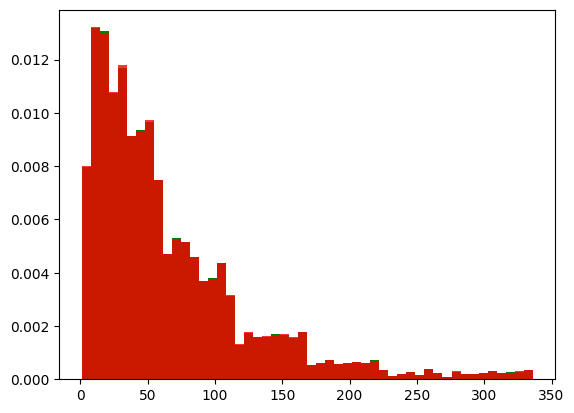

In [38]:
plt.hist(df['training_hours'],bins=50,density=True,color='green')
plt.hist(new_df['training_hours'],bins=50,density=True,color='red',alpha=0.8)

<Axes: ylabel='Density'>

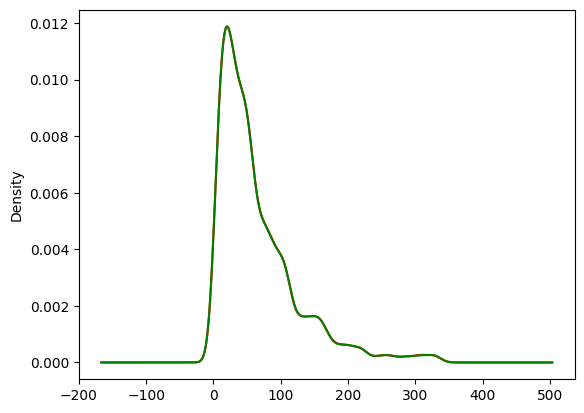

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

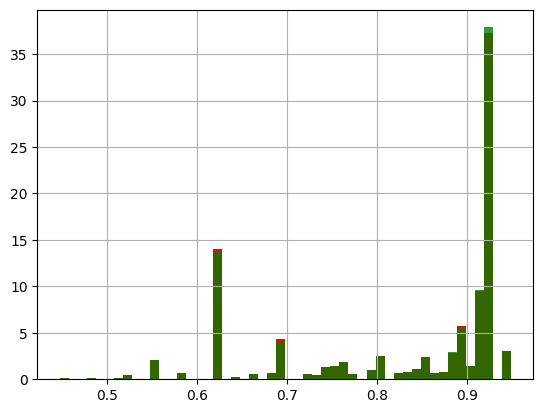

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

In [43]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [48]:
df['enrolled_university'].value_counts() / len(df)

enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64

In [52]:
df['education_level'].value_counts() / len(df), df['education_level'].value_counts() / len(new_df)

(education_level
 Graduate          0.605387
 Masters           0.227633
 High School       0.105282
 Phd               0.021610
 Primary School    0.016077
 Name: count, dtype: float64,
 education_level
 Graduate          0.675009
 Masters           0.253812
 High School       0.117390
 Phd               0.024095
 Primary School    0.017926
 Name: count, dtype: float64)